In [1]:
import tensorflow as tf

print("TensorFlow Verion: ", tf.__version__)


TensorFlow Verion:  2.15.0


In [2]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Add the explicit Input layer to fix the Keras 3 warning
model.add(layers.Input(shape=(224, 224, 3)))

# Now add your first Convolutional block
model.add(layers.Conv2D(32, (3,3), activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
Total params: 896 (3.50 KB)
Trainable params: 896 (3.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [3]:
model.add(layers.Conv2D(64, (3,3), activation= "relu"))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation= "relu"))
model.add(layers.MaxPooling2D((2,2)))

print("CNN feature extractor completed")

CNN feature extractor completed


In [4]:
# Flatten feature maps

model.add(
    layers.Flatten()
)


# Fully connected layer

model.add(
    layers.Dense(
        128,
        activation="relu"
    )
)


# Dropout to reduce overfitting

model.add(
    layers.Dropout(
        0.5
    )
)

# Output layer for 3 classes

model.add(
    layers.Dense(
        3,
        activation="softmax"
    )
)


print("CNN classification head completed")

CNN classification head completed


In [5]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

model.summary()


Model compiled successfully
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin

In [6]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


print("Early stopping configured")

Early stopping configured


In [7]:
import numpy as np


X_train = np.random.rand(
    30,
    224,
    224,
    3
)


y_train = tf.keras.utils.to_categorical(
    np.random.randint(0,3,30),
    3
)


history = model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/3


1/1 [==============================] - 2s 2s/step - loss: 1.1192 - accuracy: 0.4167 - val_loss: 6.7759 - val_accuracy: 0.3333
Epoch 2/3
1/1 [==============================] - 1s 519ms/step - loss: 6.5097 - accuracy: 0.3750 - val_loss: 4.4943 - val_accuracy: 0.1667
Epoch 3/3
1/1 [==============================] - 0s 430ms/step - loss: 4.9703 - accuracy: 0.3333 - val_loss: 1.6924 - val_accuracy: 0.1667


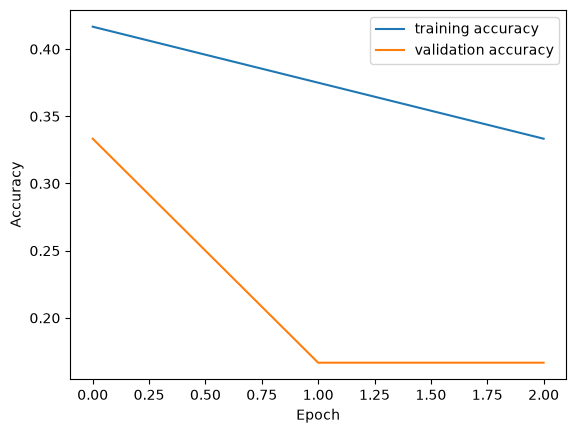

In [8]:
import matplotlib.pyplot as plt


plt.plot(
    history.history["accuracy"],
    label="training accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="validation accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

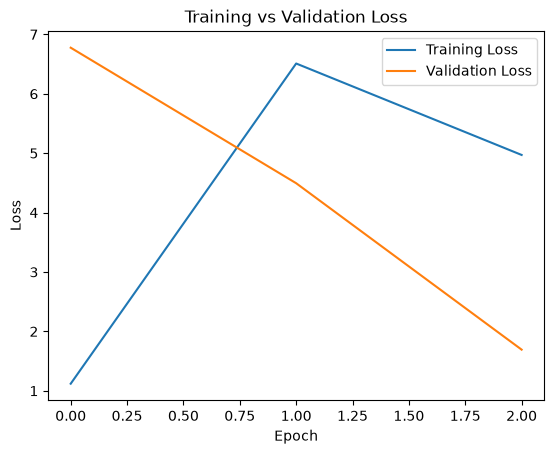

In [9]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [10]:
print("Final Training Accuracy :",
      round(history.history["accuracy"][-1]*100,2),
      "%")

print("Final Validation Accuracy :",
      round(history.history["val_accuracy"][-1]*100,2),
      "%")

Final Training Accuracy : 33.33 %
Final Validation Accuracy : 16.67 %


In [11]:
model.save("baseline_cnn.keras")

print("Baseline CNN model saved successfully.")

Baseline CNN model saved successfully.


In [12]:
from tensorflow.keras.models import load_model

loaded_model = load_model("baseline_cnn.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [13]:
print("="*50)
print("Baseline CNN Project Completed")
print("="*50)

print("TensorFlow Version :", tf.__version__)
print("Optimizer : Adam")
print("Loss Function : Categorical Crossentropy")
print("Activation : ReLU")
print("Output Activation : Softmax")

print("\nModel is ready for integration with the preprocessing pipeline.")

Baseline CNN Project Completed
TensorFlow Version : 2.15.0
Optimizer : Adam
Loss Function : Categorical Crossentropy
Activation : ReLU
Output Activation : Softmax

Model is ready for integration with the preprocessing pipeline.
